In [1]:
# Dataset taken from : https://huggingface.co/datasets/dair-ai/emotion

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from datasets import load_dataset
emotion = load_dataset('emotion')
emotion.set_format(type = 'pandas')

/home/devcontainers/miniconda3/envs/agents-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating test split: 100%|██████████| 2000/2000 [00:00<00:00, 721600.69 examples/s]


In [21]:
df = emotion['train'][:]
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [22]:
classes = emotion['train'].features['label'].names
df['label_name'] = df['label'].apply(lambda x : classes[x])
df.head()

,text,label,label_name
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


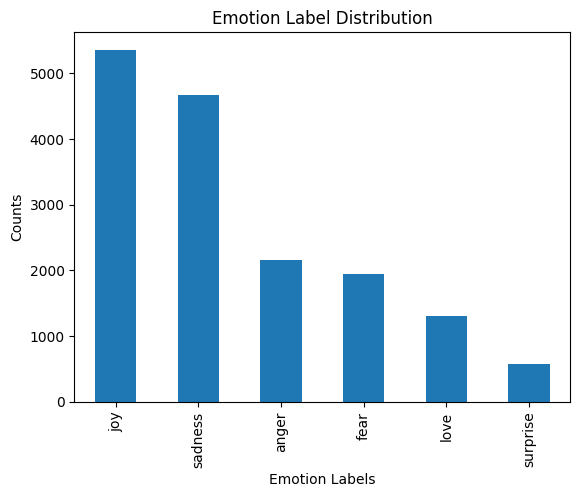

In [23]:
label_counts = df['label_name'].value_counts()
label_counts.plot(kind='bar')
plt.title('Emotion Label Distribution')
plt.xlabel('Emotion Labels')
plt.ylabel('Counts')
plt.show()

In [24]:
words_per_sentence = df['text'].apply(lambda x : len(x.split()))
df['words_per_sentence'] = words_per_sentence
df.head()

,text,label,label_name,words_per_sentence
0,i didnt feel humiliated,0,sadness,4
1,i can go from feeling so hopeless to so damned...,0,sadness,21
2,im grabbing a minute to post i feel greedy wrong,3,anger,10
3,i am ever feeling nostalgic about the fireplac...,2,love,18
4,i am feeling grouchy,3,anger,4


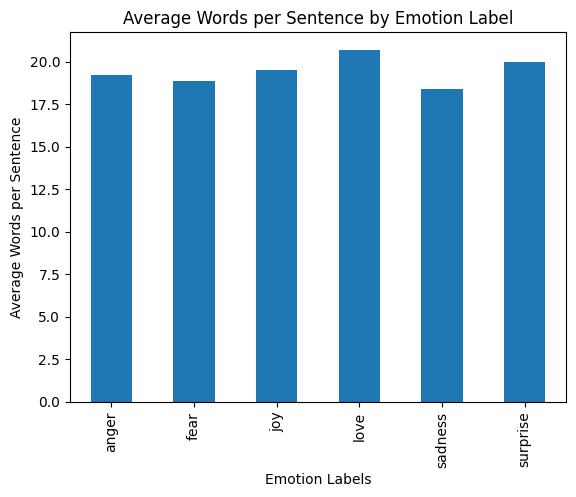

In [25]:
words_per_label = df.groupby('label_name')['words_per_sentence'].mean()
words_per_label.plot(kind='bar')
plt.title('Average Words per Sentence by Emotion Label')
plt.xlabel('Emotion Labels')
plt.ylabel('Average Words per Sentence')
plt.show()

In [26]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=6)

2025-08-17 17:30:51.034678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755432051.162445   26008 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755432051.198405   26008 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1755432051.464203   26008 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755432051.464275   26008 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1755432051.464277   26008 computation_placer.cc:177] computation placer alr

In [27]:
sample_text = "The weather is very good today !"
encoded_text = tokenizer(sample_text)
print(encoded_text)
tokens = tokenizer.convert_ids_to_tokens(encoded_text['input_ids'])
print(tokens)

{'input_ids': [101, 1996, 4633, 2003, 2200, 2204, 2651, 999, 102], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}
['[CLS]', 'the', 'weather', 'is', 'very', 'good', 'today', '!', '[SEP]']


In [30]:
emotion.reset_format()

def tokenize(batch):
    return tokenizer(batch['text'], padding = True, truncation = True)

emotions_encoded = emotion.map(tokenize, batched = True, batch_size = None)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map: 100%|██████████| 2000/2000 [00:00<00:00, 28466.55 examples/s]


In [31]:
emotions_encoded

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 2000
    })
})